In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import f1_score

In [2]:
cohorts = {
    "Healthy": ["HS"],
    "Neuro": ["CIPN", "PD", "RIL"],
    "Ortho": ["ACL", "KOA", "HOA"]}


In [3]:
a = "PD"
key = [k for k, v in cohorts.items() if a in v][0]
print(key)

Neuro


In [4]:
import random

def subj_generator(cohort, disease, num):
  subj = f'{disease}_{num}'
  if cohort == "Healthy":
    mi = 0.75
    ma = 0.99
  elif cohort == "Neuro":
    mi = 0.4
    ma = 0.94
  else:
    mi = 0.6
    ma = 0.9

  score = random.uniform(mi, ma)
  return [subj, cohort, score]

In [5]:
data = []
for i in range(500):
  cohort = random.choice(list(cohorts.keys()))
  disease = random.choice(cohorts[cohort])
  data.append(subj_generator(cohort, disease, i))

In [6]:
df = pd.DataFrame(data, columns=["subject", "cohort", "f1"])
df.head()

,subject,cohort,f1
0,ACL_0,Ortho,0.793231
1,CIPN_1,Neuro,0.723296
2,HS_2,Healthy,0.966836
3,CIPN_3,Neuro,0.596962
4,KOA_4,Ortho,0.696939


In [7]:
diseases = []
for subj in df['subject']:
  diseases.append(subj.split("_")[0])

df['Disease'] = diseases

In [8]:
def plot_f1_by_cohort(df, cohorts, title="F1  by cohort", ax=None):
    stats = (df.groupby("Disease")["f1"]
                .agg(["mean", "std", "count"])
                .sort_values("mean", ascending=False))
    stats["std"] = stats["std"].fillna(0.0)  
    COLOR_MAP = {
        'HS':   ('Healthy',        'lightgreen'),
        'ACL':  ('Orthopaedic',    'lightcoral'),
        'HOA':  ('Orthopaedic',    'lightcoral'),
        'KOA':  ('Orthopaedic',    'lightcoral'),
        'CIPN': ('Neurological',   'lightblue'),
        'CVA':  ('Neurological',   'lightblue'),
        'PD':   ('Neurological',   'lightblue'),
        'RIL':  ('Neurological',   'lightblue'),
    }

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    seen_labels = set()
    for disease, stats_row in stats.iterrows():
        cohort, color = COLOR_MAP.get(disease, ('Other', 'gray'))
        label = cohort if cohort not in seen_labels else "_nolegend_"
        seen_labels.add(cohort)

        scores = df[df['Disease'] == disease]['f1'].values
        bar = ax.bar(disease, scores.mean(), yerr=scores.std(),
                     capsize=5, color=color, alpha=0.8, label=label)
        ax.bar_label(bar, fmt='%.3f', fontsize=8)

    global_mean = df['f1'].mean()

    ax.axhline(global_mean, color='black', linestyle='--', alpha=0.7, label=f'Global mean {global_mean:.3f}')
    ax.set_ylim(0, 1); ax.set_ylabel('Mean Macro F1')
    ax.set_title('By clinical cohort')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.4)

    plt.tight_layout()
    return stats

,mean,std,count
Disease,,,
HS,0.870537,0.064996,165
KOA,0.765455,0.091987,59
ACL,0.757447,0.092685,50
HOA,0.733902,0.083995,57
CIPN,0.692543,0.151167,57
RIL,0.679575,0.159006,56
PD,0.651787,0.157479,56


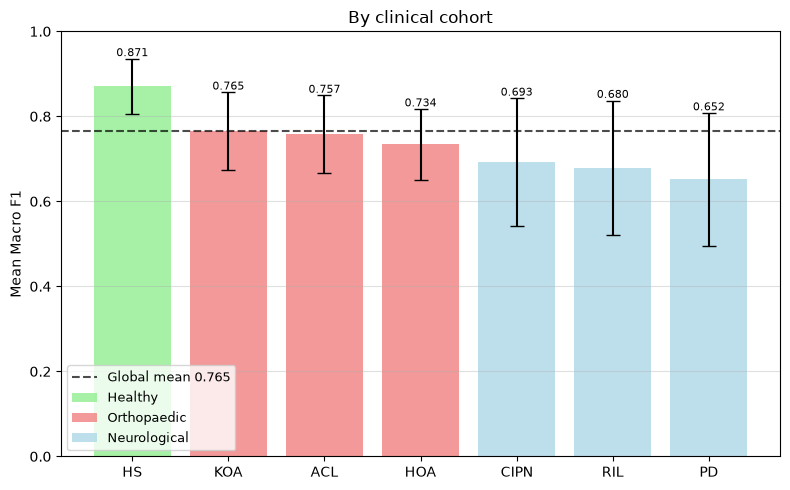

In [9]:
plot_f1_by_cohort(df, cohorts, title="F1  by cohort", ax=None)